In [7]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "olive"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [3]:
import os
import shutil

# 1. 找到 Scikit-Learn 默认的“藏身之处” (通常是 ~/scikit_learn_data)
default_path = os.path.expanduser("~/scikit_learn_data")

print(f"正在检查默认缓存路径: {default_path}")

# 2. 如果存在，直接删除
if os.path.exists(default_path):
    try:
        shutil.rmtree(default_path)
        print(f"✅ 成功删除默认缓存目录: {default_path}")
        print("之前的缓存（或者下载了一半的文件）已被清理，空间已释放。")
    except Exception as e:
        print(f"❌ 删除失败，请检查权限: {e}")
else:
    print("✅ 没发现默认缓存目录，你的硬盘很干净。")

正在检查默认缓存路径: /Users/sususu/scikit_learn_data
✅ 成功删除默认缓存目录: /Users/sususu/scikit_learn_data
之前的缓存（或者下载了一半的文件）已被清理，空间已释放。


In [4]:
from sklearn.datasets import fetch_olivetti_faces
import os

# 1. 获取当前 Jupyter Notebook 所在的文件夹路径
current_folder = os.getcwd()

# 2. 指定一个新的子文件夹，专门存数据，免得乱
# 也就是：你的Notebook目录/my_local_data
local_data_path = os.path.join(current_folder, "my_local_data")

if not os.path.exists(local_data_path):
    os.makedirs(local_data_path)

print(f"准备将数据下载到这里: {local_data_path}")

# 3. 开始下载 (指定 data_home)
# download_if_missing=True 表示如果本地有了就不再下了
print("⏳ 开始下载数据 (约 4MB)...")
faces = fetch_olivetti_faces(data_home=local_data_path, download_if_missing=True)

print("✅ 下载完成！")
print("你可以去文件夹里确认一下，能不能看到 'my_local_data' 这个文件夹。")

准备将数据下载到这里: /Users/sususu/Documents/my_ai_project/Machine Learning /09_unsupervised_learning.ipynb/my_local_data
⏳ 开始下载数据 (约 4MB)...
downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /Users/sususu/Documents/my_ai_project/Machine Learning /09_unsupervised_learning.ipynb/my_local_data
✅ 下载完成！
你可以去文件夹里确认一下，能不能看到 'my_local_data' 这个文件夹。


正在使用 M3 芯片进行 PCA 降维...
✅ 模型训练完毕！准确率: 0.9500


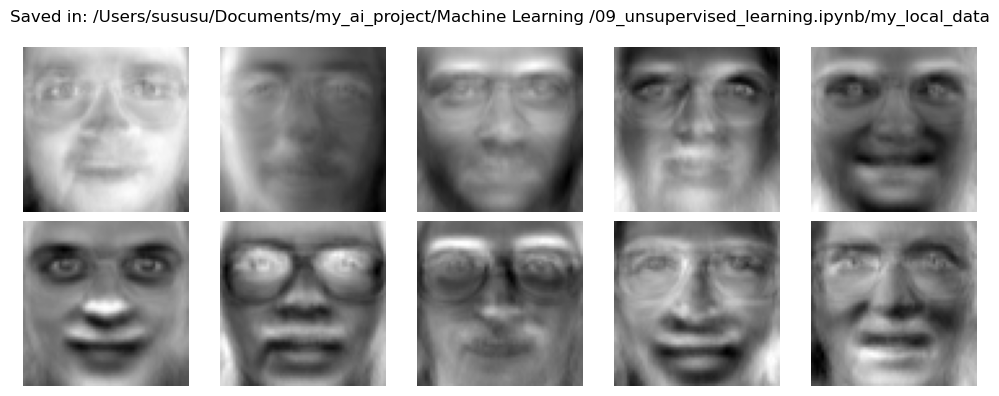

In [11]:
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# 提取数据
X = faces.data
y = faces.target

# --- M3 芯片性能全开 ---
# 降维：把 4096维 压缩到 64维 (保留90%的信息)
print("正在使用 M3 芯片进行 PCA 降维...")
pca = PCA(n_components=0.9, random_state=42)
X_reduced = pca.fit_transform(X)

# 拆分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, random_state=42)

# 训练模型
clf = LogisticRegression(max_iter=10000)
clf.fit(X_train, y_train)

print(f"✅ 模型训练完毕！准确率: {clf.score(X_test, y_test):.4f}")

# 可视化特征脸
eigenfaces = pca.components_.reshape((pca.n_components_, 64, 64))
plt.figure(figsize=(10, 4))
plt.suptitle(f"Saved in: {local_data_path}", fontsize=12)
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(eigenfaces[i], cmap='gray')
    plt.axis('off')

save_fig("eigenfaces")
plt.show()
